# UGRID unstructured-mesh files

Unstructured meshes follow the UGRID convention and use the `UgridDataset` API (nodes, faces, connectivity) rather than the gridded raster API.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon

from pyramids.netcdf import NetCDF, UgridDataset
from pyramids.feature import FeatureCollection

DATA = Path('../../../../examples/data/netcdf/samples')

2026-06-18 02:46:59 | INFO | pyramids.base.config | Logging is configured.


## `ugrid__6v__1d5-2d1.nc` — a 2-D face/node mesh

A UXARRAY-style mesh declaring topology via `cf_role` on the connectivity variable.

**Open the mesh**

In [2]:
ug = UgridDataset.read_file(DATA / 'ugrid__6v__1d5-2d1.nc')
ug

UgridDataset(mesh='mesh2d', n_node=16, n_face=4, n_edge=0, variables=[])

**Mesh dimensions**

In [3]:
print('nodes:', ug.n_node, '| faces:', ug.n_face, '| edges:', ug.n_edge)
print('mesh:', ug.mesh)
print('bounds:', ug.bounds)

nodes: 16 | faces: 4 | edges: 0
mesh: <pyramids.netcdf.ugrid.mesh.Mesh2d object at 0x000001C5F0D08EC0>
bounds: (-0.3252372145652771, -0.26931479573249817, 0.38283485174179077, 0.2782424986362457)


**Plot the mesh outline**

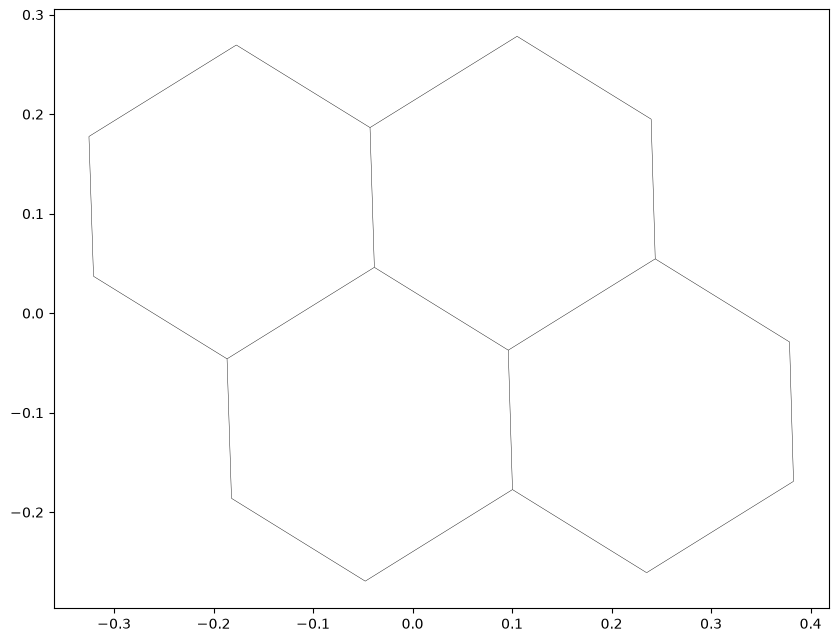

In [4]:
ug.plot_outline()

**Face polygons as a GeoDataFrame**

In [5]:
ug.to_geodataframe()

,geometry
0,"POLYGON ((-0.03841 0.04606, -0.18645 -0.0459, ..."
1,"POLYGON ((0.24388 0.05458, 0.23977 0.19501, 0...."
2,"POLYGON ((-0.03841 0.04606, -0.04275 0.18654, ..."
3,"POLYGON ((0.1004 -0.1773, 0.23522 -0.26082, 0...."


## Data-only UGRID files

`ugrid__1v__3d1.nc` and `ugrid__1v__1d1.nc` carry data on a mesh dimension but no topology variable, so they are opened with the regular `NetCDF` reader.

In [6]:
nc = NetCDF.read_file(DATA / 'ugrid__1v__3d1.nc')
print('variables:', nc.variable_names)
print('dimensions:', dict(nc.dimension_sizes))

variables: ['multi_dim_data']
dimensions: {'time': 8, 'lev': 8, 'n_face': 4}


In [7]:
nc = NetCDF.read_file(DATA / 'ugrid__1v__1d1.nc')
print('variables:', nc.variable_names)
print('dimensions:', dict(nc.dimension_sizes))

variables: ['psi']
dimensions: {'ncol': 5400}
